# Домашнее задание. Решение конкурса на kaggle.com

Это домашнее задание посвящено полноценному решению задачи машинного обучения.

Есть две части этого домашнего задания:

### Отправить ваши предсказания в Stepik.
За прохождение определенных порогов будут начисляться баллы. Эта часть оценивается из 5 баллов.

1) $1.00 \geqslant score \geqslant 0.84$ --- 5 баллов

2) $0.84 > score \geqslant 0.77$ --- 4 балла

3) $0.77 > score \geqslant 0.70$ --- 3 балла

4) $0.70 > score \geqslant 0.65$ --- 2 балла

5) $0.65 > score \geqslant 0.6$ --- 1 балл

6) $0.60 > score$ --- 0 баллов

Для этого мы предварительно разделили данные в задании на две части.
* `train.csv`. На этом наборе данных вам необходимо создать и обучить модель. Подробное описание файла есть в ноутбуке.
* `test.csv`. В каждой строчке файла `test.csv` указаны признаки тестовых объектов. Предсказания для этого набора необходимо записать в файл submission.csv и сдать в соответствующий шаг на Stepik. Количество попыток ограничено 100 штук.

Отправлять в Stepik вы будете файл с ответами `my_submission.csv`. В этом файле вам необходимо для каждого объекта из датасета предсказать вероятность класса 1. Мы подготовили для вас файл с примером посылки `submission.csv`. Ваш файл должен быть оформлен таким же образом. В ноутбуке есть пример оформления файла посылки. Для отправки файла с предсказаниями на Stepik есть отдельный шаг.

### Сделать полноценный отчет о вашей работе.
Опишите, как вы обработали данные, какие модели попробовали и какие результаты получились (максимум 10 баллов). За каждую выполненную часть будет начислено определенное количество баллов. В этом пункте вам необходимо отправить файл в формате .ipynb на Stepik --- для этого в домашнем задании есть отдельный шаг. Этот пункт оценивается из 10 баллов.

**Вторая часть будет проверяться в формате peer-review. Т.е. вашу посылку на Stepik будут проверять 3 других студента, и медианное значение их оценок будет выставлено. Чтобы получить баллы, вам также нужно будет проверить трех других учеников. Это станет доступно после того, как вы сдадите задание сами.**

### Контест на Kaggle
Для вашего удобства мы подготовили [контест на Kaggle](https://www.kaggle.com/c/advanced-dls-spring-2021/). Тестирующая система на Kaggle выдает те же баллы, что и Stepik. Мы рекомендуем в качестве основной тестирующей системы использовать именно Kaggle, а затем сдать лучшую посылку на Stepik. Так вы привыкните работать с Kaggle.

Проблема для российских пользователей Kaggle заключается в том, что подтверждение аккаунта по номеру телефона работает с перебоями или не работает вообще. Без подтвержденного номера телефона вы не сможете совершать посылки в kaggle. Если у вас возникла такая проблема, мы советуем следующие шаги:
* Попробовать зарегистрировать аккаунт с аутентификацией через gmail. В таком случае, аккаунт должен работать без подтверждения номера телефона.
* Если у вас есть не российский номер, используйте его для верификации аккаунта.
* Если на номер телефона не приходит смс для верификации аккаунта, обратитесь в службу поддержки kaggle. Они с переменным успехом умеют подтверждать аккаунты вручную.
* Если все же подтвердить аккаунт и получить доступ к сдаче заданий не удалось, используйте только сдачу в Stepik.

### Несколько замечаний по выполнению работы
* Во всех пунктах указания это минимальный набор вещей, которые стоит сделать. Если вы можете сделать какой-то шаг лучше или добавить что-то свое --- дерзайте!
* Пожалуйста, перед сдачей ноутбука убедитесь, что работа чистая и понятная. Это значительно облегчит проверку и повысит ваши ожидаемые баллы.
* Если у вас будут проблемы с решением или хочется совета, то пишите в наш чат в телеграме.


Данные: [train.csv](https://drive.google.com/file/d/1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K/view?usp=share_link),
[test.csv](https://drive.google.com/file/d/1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r/view?usp=share_link), [submission.csv](https://drive.google.com/file/d/199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y/view?usp=share_link).

Если ссылки на данные не работают, их можно скачать [на Kaggle](https://www.kaggle.com/competitions/advanced-dls-spring-2021/data).

# Как проверять?

Ставьте полный балл, если выполнены все рекомендации или сделано что-то более интересное и сложное. За каждый отсустствующий пункт из рекомендации снижайте 1 балл.

**Если решение верное, но не удовлетворяет вашим эстетическим предпочтениям, за это баллы снижать не нужно.**

# Метрика

Перед решением любой задачи важно понимать, как будет оцениваться ваше решение. В данном случае мы используем стандартную для задачи классификации метрику ROC-AUC. Ее можно вычислить, используя только предсказанные вероятности и истинные классы без конкретного порога классификации + она раотает даже если классы в данных сильно несбалансированны (примеров одного класса в десятки раз больше примеров длугого). Именно поэтому она очень удобна для соревнований.

Посчитать ее легко:


In [4]:
from sklearn.metrics import roc_auc_score

y_true = [0, 1, 1, 0, 1]

y_predictions = [0.1, 0.9, 0.4, 0.6, 0.61]

roc_auc_score(y_true, y_predictions)

0.8333333333333333

# Первая часть. Исследование

In [5]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

## Загрузка данных (2 балла)

1) Посмотрите на случайные строчки.

2) Посмотрите, есть ли в датасете незаполненные значения (nan'ы) с помощью data.isna() или data.info() и, если нужно, замените их на что-то. Будет хорошо, если вы построите табличку с количеством nan в каждой колонке.

In [6]:
"""
!gdown 1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K  # train.csv
!gdown 1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r  # test.csv
!gdown 199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y  # submission.csv"
"""

'\n!gdown 1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K  # train.csv\n!gdown 1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r  # test.csv\n!gdown 199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y  # submission.csv"\n'

In [7]:
data = pd.read_csv("./train.csv" )

In [8]:
data["TotalSpent"] = data["TotalSpent"].replace(' ', np.nan)
data["TotalSpent"] = data["TotalSpent"].astype(float)


In [9]:
m = data["TotalSpent"].dropna()
median = np.median(m)
data["TotalSpent"] = data["TotalSpent"].replace(np.nan, median)

In [10]:
data.head()

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
0,55,19.50,1026.35,Male,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,0
1,72,25.85,1872.20,Male,0,Yes,No,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),0
2,1,75.90,75.90,Male,0,No,No,Yes,No,Fiber optic,No,No,No,Yes,No,No,Month-to-month,Yes,Electronic check,1
3,32,79.30,2570.00,Female,1,Yes,No,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Mailed check,0
4,60,115.25,6758.45,Female,0,Yes,Yes,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),0


In [11]:
# Для вашего удобства списки с именами разных колонок

# Числовые признаки
num_cols = ["ClientPeriod", "MonthlySpending", "TotalSpent"]

# Категориальные признаки
cat_cols = [
    "Sex",
    "IsSeniorCitizen",
    "HasPartner",
    "HasChild",
    "HasPhoneService",
    "HasMultiplePhoneNumbers",
    "HasInternetService",
    "HasOnlineSecurityService",
    "HasOnlineBackup",
    "HasDeviceProtection",
    "HasTechSupportAccess",
    "HasOnlineTV",
    "HasMovieSubscription",
    "HasContractPhone",
    "IsBillingPaperless",
    "PaymentMethod",
]

feature_cols = num_cols + cat_cols
target_col = "Churn"

In [12]:
data.isna().sum()

ClientPeriod                0
MonthlySpending             0
TotalSpent                  0
Sex                         0
IsSeniorCitizen             0
HasPartner                  0
HasChild                    0
HasPhoneService             0
HasMultiplePhoneNumbers     0
HasInternetService          0
HasOnlineSecurityService    0
HasOnlineBackup             0
HasDeviceProtection         0
HasTechSupportAccess        0
HasOnlineTV                 0
HasMovieSubscription        0
HasContractPhone            0
IsBillingPaperless          0
PaymentMethod               0
Churn                       0
dtype: int64

## Анализ данных (3 балла)

1) Для численных призанков постройте гистограмму (*plt.hist(...)*) или boxplot (*plt.boxplot(...)*). Для категориальных посчитайте количество каждого значения для каждого признака. Для каждой колонки надо сделать *data.value_counts()* и построить bar диаграммы *plt.bar(...)* или круговые диаграммы *plt.pie(...)* (хорошо, елси вы сможете это сделать на одном гарфике с помощью *plt.subplots(...)*).

2) Посмотрите на распределение целевой переменной и скажите, являются ли классы несбалансированными.

3) (Если будет желание) Поиграйте с разными библиотеками для визуализации - *sns*, *pandas_visual_analysis*, etc.

Второй пункт очень важен, потому что существуют задачи классификации с несбалансированными классами. Например, это может значить, что в датасете намного больше примеров 0 класса. В таких случаях нужно 1) не использовать accuracy как метрику 2) использовать методы борьбы с imbalanced dataset (обычно если датасет сильно несбалансирован, т.е. класса 1 в 20 раз меньше класса 0).

(array([3898.,    0., 1384.]),
 array([0.        , 0.33333333, 0.66666667, 1.        ]),
 <BarContainer object of 3 artists>)

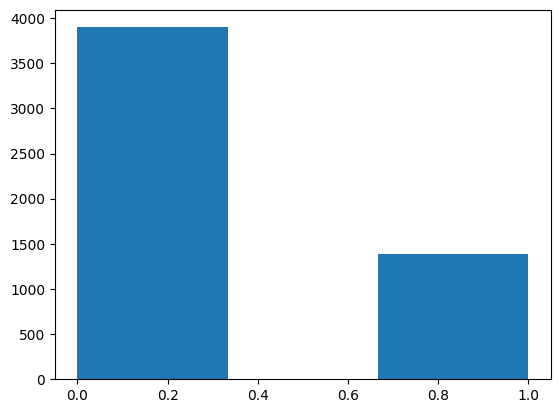

In [13]:
plt.hist(data["Churn"], bins = 3)

# Для меня разность количества классов в три раза = не сбалансированость 

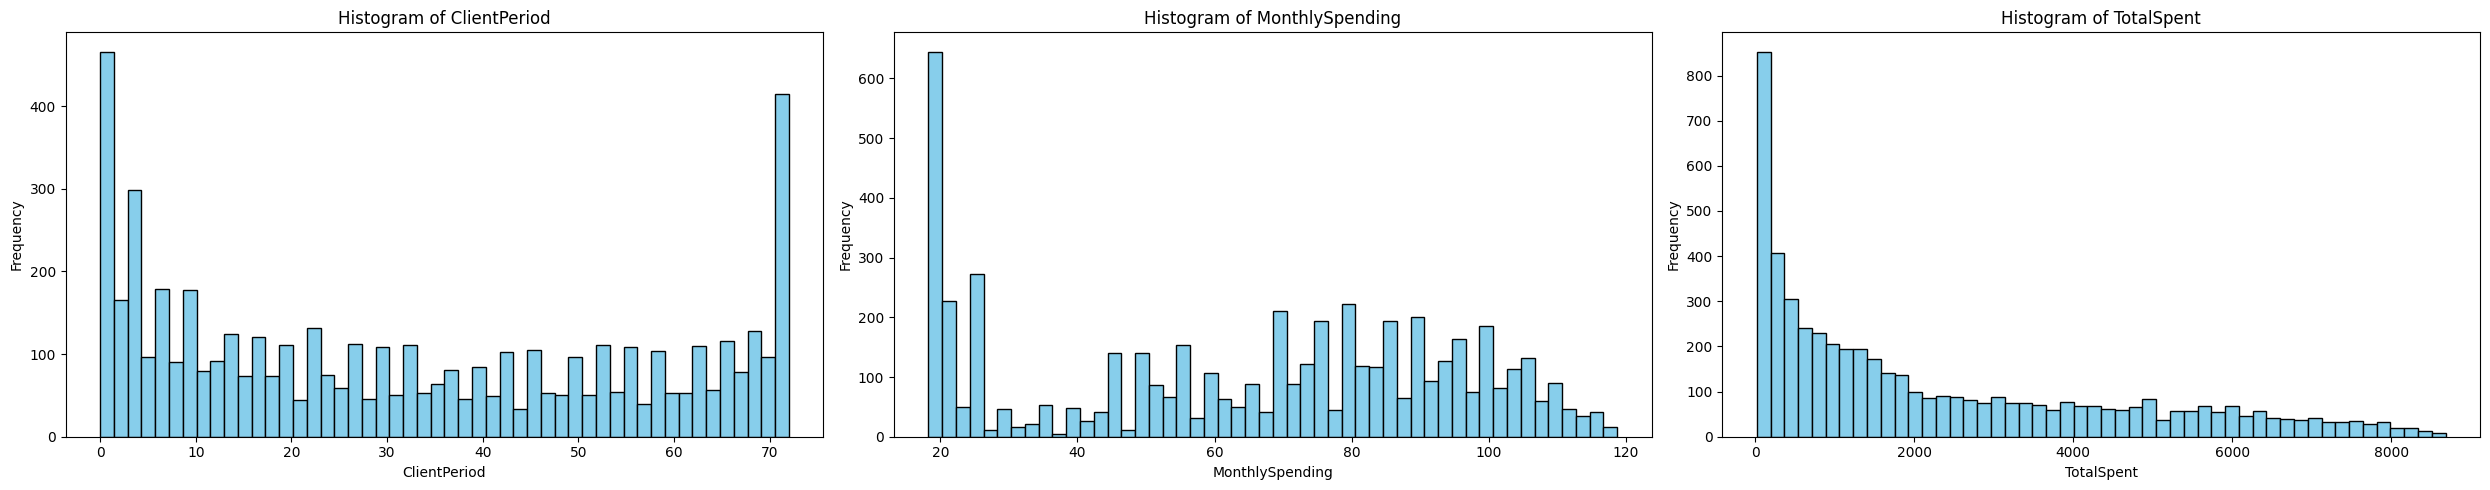

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(25, 5))

for i, num in enumerate(num_cols):
    axes[i].hist(data[num], bins=50, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Histogram of {num}')
    axes[i].set_xlabel(num)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

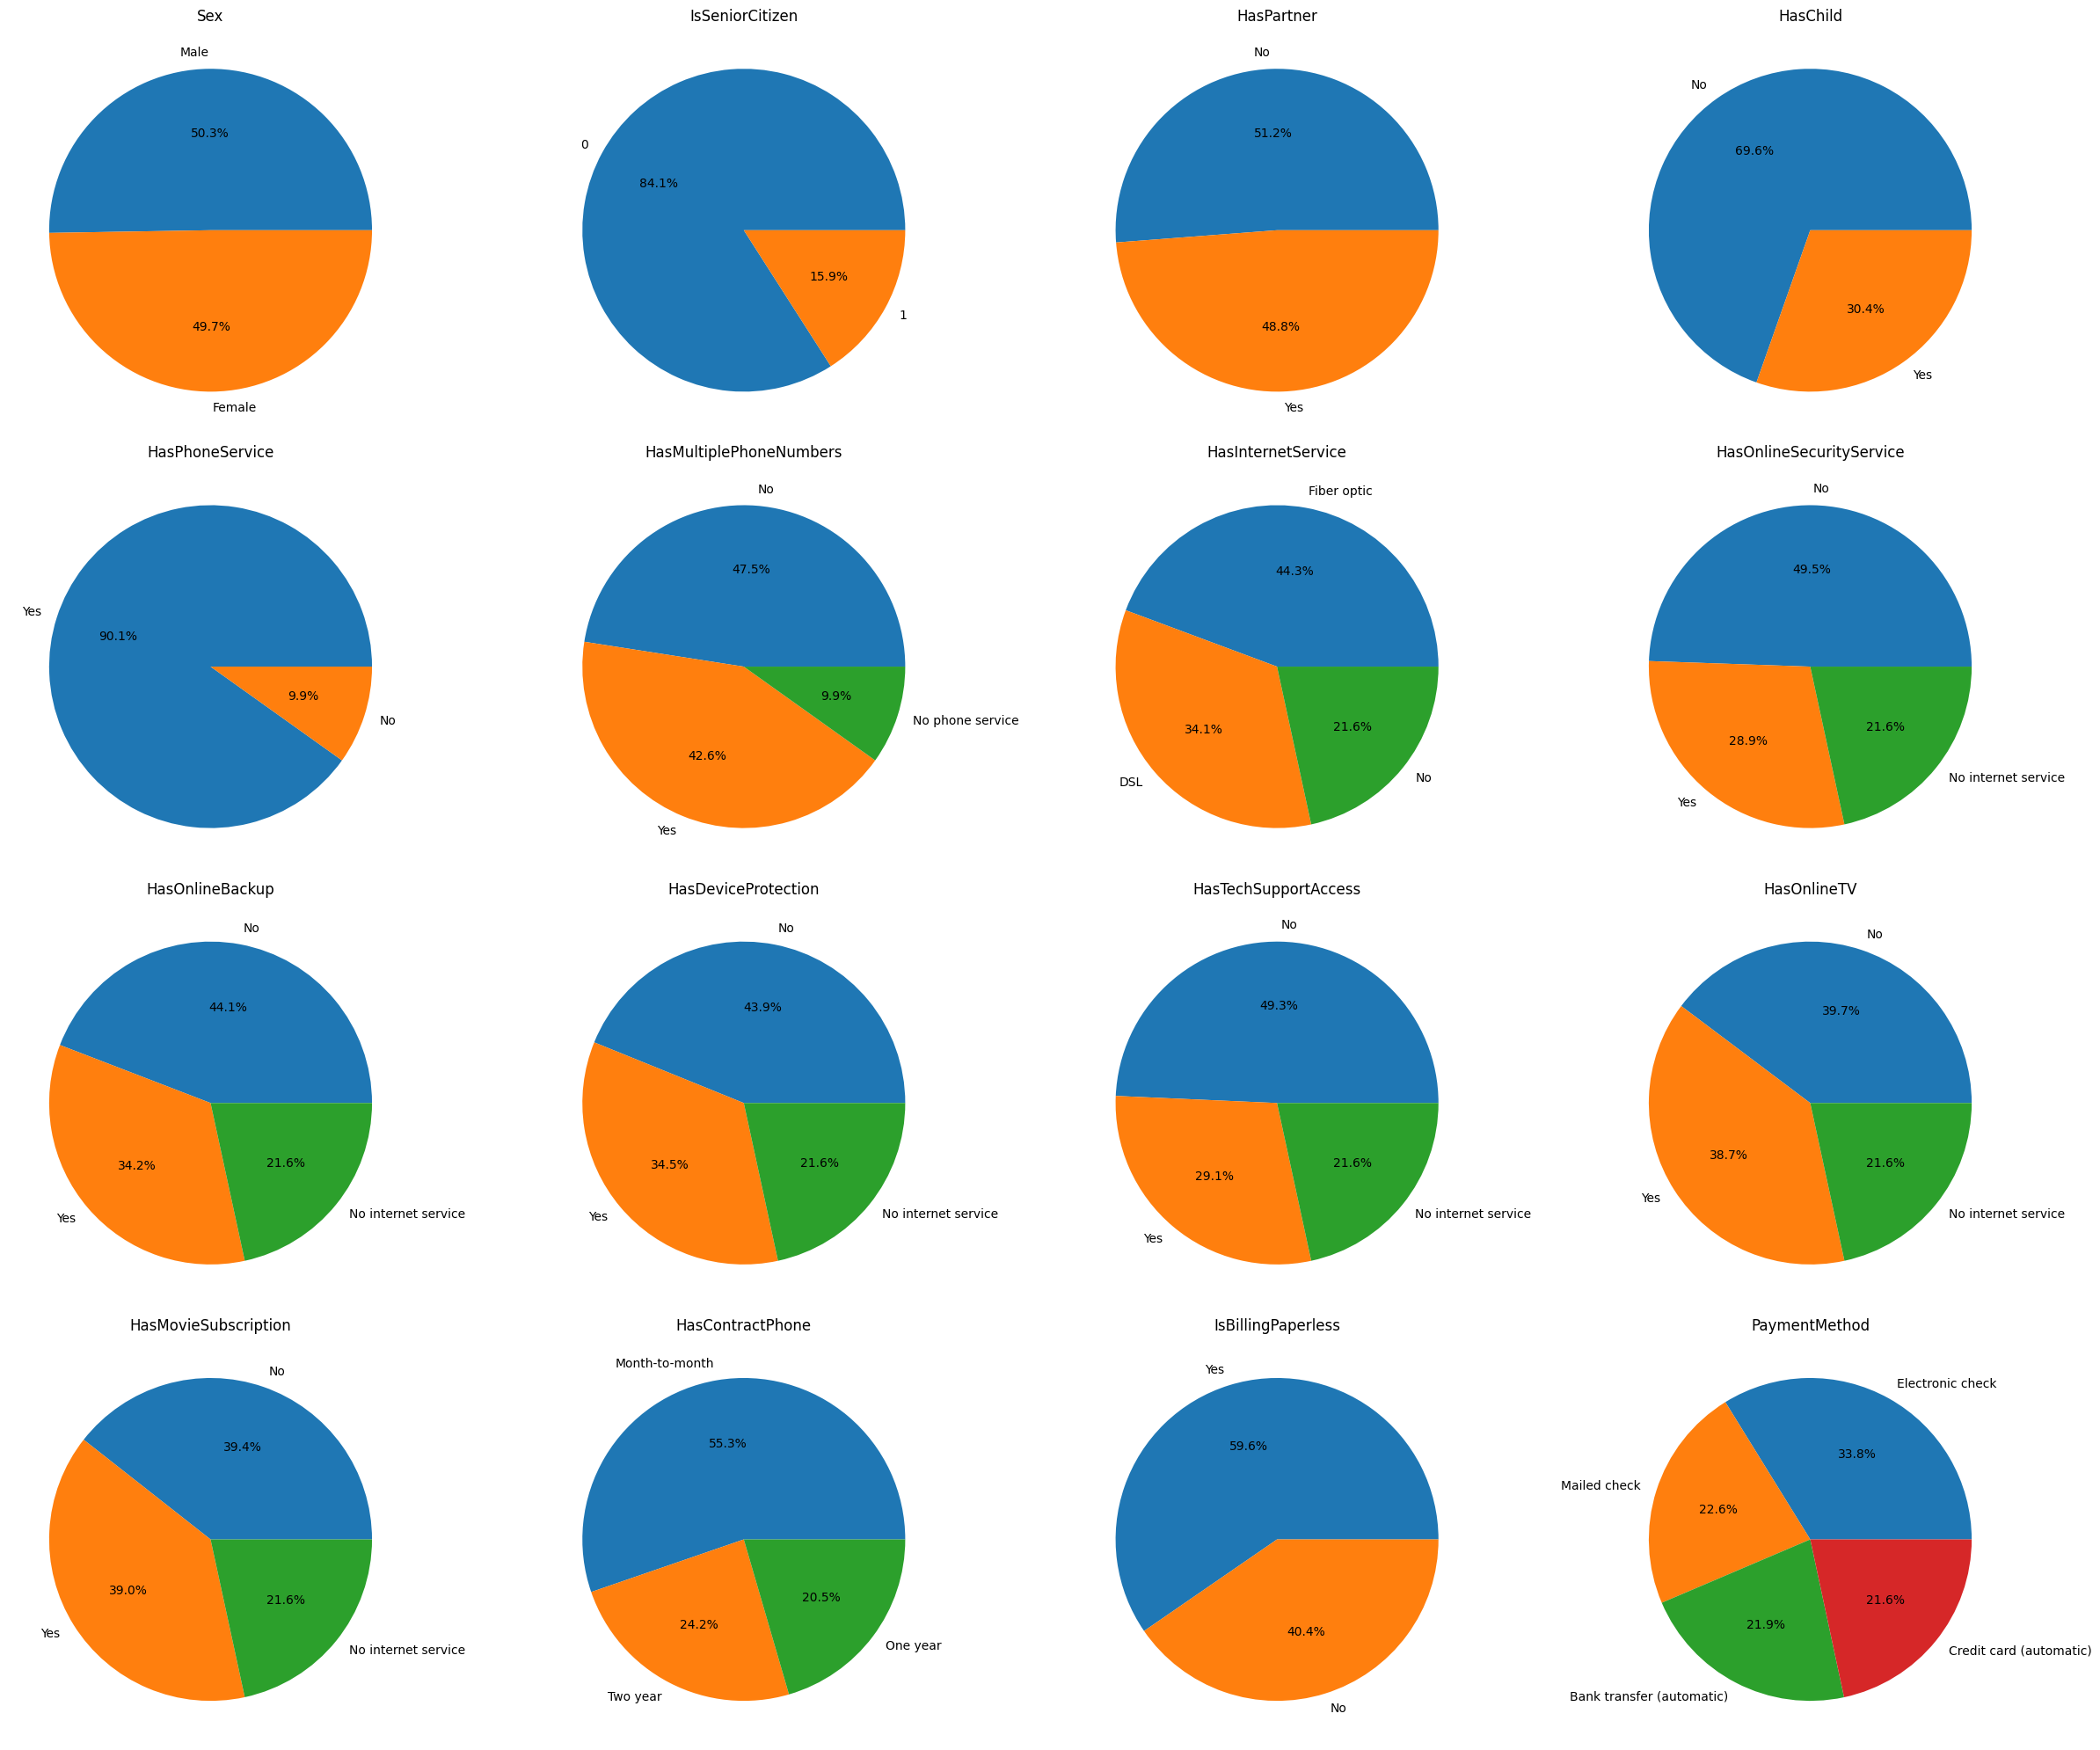

In [15]:
fig, axes = plt.subplots(4, 4, figsize=(25, 20))
axes = axes.flatten()

for i, title in enumerate(cat_cols):
    value_counts = data[title].value_counts()
    axes[i].pie(value_counts, labels=value_counts.index, autopct="%1.1f%%")
    axes[i].set_title(title)

plt.tight_layout()
plt.show()

Кажется что TotalSpent = ClientPeriod * MonthlySpending, но это не так 

(Дополнительно) Если вы нашли какие-то ошибки в данных или выбросы, то можете их убрать. Тут можно поэксперементировать с обработкой данных как угодно, но не за баллы.

## Применение линейных моделей (3 балла)

1) Обработайте данные для того, чтобы к ним можно было применить LogisticRegression. Т.е. отнормируйте числовые признаки, а категориальные закодируйте с помощью one-hot-encoding'а.

2) С помощью кроссвалидации или разделения на train/valid выборку протестируйте разные значения гиперпараметра C и выберите лучший (можно тестировать С=100, 10, 1, 0.1, 0.01, 0.001) по метрике ROC-AUC.

Если вы разделяете на train/valid, то используйте LogisticRegressionCV. Он сам при вызове .fit() подберет параметр С. (не забудьте передать scroing='roc_auc', чтобы при кроссвалидации сравнивались значения этой метрики, и refit=True, чтобы при потом модель обучилась на всем датасете с лучшим параметром C).


(более сложный вариант) Если вы будете использовать кроссвалидацию, то преобразования данных и LogisticRegression нужно соединить в один Pipeline с помощью make_pipeline, как это делалось во втором семинаре. Потом pipeline надо передать в GridSearchCV. Для one-hot-encoding'a можно испльзовать комбинацию LabelEncoder + OneHotEncoder (сначала превращаем строчки в числа, а потом числа првращаем в one-hot вектора.)

In [16]:
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import (
    StandardScaler,
    RobustScaler,
    LabelEncoder,
    OneHotEncoder,
)
from sklearn.pipeline import make_pipeline

In [17]:
# TRAIN

#OHE
categorial_data = data[cat_cols]
dummy_features = pd.get_dummies(categorial_data, drop_first=True)
dummy_features = dummy_features.astype(int)

numeric_data = data[num_cols]

#Нормализация
scaler = StandardScaler()
numeric_data_scaled = scaler.fit_transform(numeric_data)

#Получение X
numeric_data_scaled = pd.DataFrame(numeric_data_scaled, columns=numeric_data.columns)
X_train_scaled = pd.concat([numeric_data_scaled, dummy_features], axis=1)


In [18]:
X_train_scaled.head()

,ClientPeriod,MonthlySpending,TotalSpent,IsSeniorCitizen,Sex_Male,HasPartner_Yes,HasChild_Yes,HasPhoneService_Yes,HasMultiplePhoneNumbers_No phone service,HasMultiplePhoneNumbers_Yes,...,HasOnlineTV_No internet service,HasOnlineTV_Yes,HasMovieSubscription_No internet service,HasMovieSubscription_Yes,HasContractPhone_One year,HasContractPhone_Two year,IsBillingPaperless_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.920767,-1.505447,-0.557323,0,1,1,1,1,0,0,...,1,0,1,0,1,0,0,0,0,1
1,1.613288,-1.294998,-0.184235,0,1,1,0,1,0,1,...,1,0,1,0,0,1,0,1,0,0
2,-1.279005,0.363737,-0.976549,0,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0
3,-0.016173,0.476418,0.123552,1,0,1,0,1,0,1,...,0,0,0,0,0,0,0,0,0,1
4,1.124450,1.667856,1.970998,0,0,1,1,1,0,1,...,0,1,0,1,0,1,0,1,0,0


In [19]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression

In [30]:
X = X_train_scaled 
y = data[target_col]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


pipeline = make_pipeline(
    LogisticRegression(max_iter=1000, random_state=42),
)

param_grid = {
    "logisticregression__C": [100, 10, 1, 0.1, 0.01, 0.001],  
}

#Инициализация GridCV
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,  
    scoring="roc_auc",  
    refit=True,
)

grid_search.fit(X_train, y_train)

#Лучшее
y_pred_proba = grid_search.predict_proba(X_valid)[:, 1]

roc_auc = roc_auc_score(y_valid, y_pred_proba)
print(f"Лучший параметр C: {grid_search.best_params_['logisticregression__C']}")
print(f"ROC-AUC на валидационной выборке: {roc_auc:.4f}")

Лучший параметр C: 100
ROC-AUC на валидационной выборке: 0.8549


Выпишите какое лучшее качество и с какими параметрами вам удалось получить,
C = 100

## Применение градиентного бустинга (2 балла)

Если вы хотите получить баллы за точный ответ, то стоит попробовать градиентный бустинг. Часто градиентный бустинг с параметрами по умолчанию даст вам 80% результата за 0% усилий.

Мы будем использовать catboost, поэтому нам не надо кодировать категориальные признаки. Catboost сделает это сам (в .fit() надо передать cat_features=cat_cols). А численные признаки нормировать для моделей, основанных на деревьях не нужно.

1) Разделите выборку на train/valid. Протестируйте catboost cо стандартными параметрами.

2) Протестируйте разные занчения параметров количества деревьев и learning_rate'а и выберите лучшую по метрике ROC-AUC комбинацию.

(Дополнительно) Есть некоторые сложности с тем, чтобы использовать CatBoostClassifier вместе с GridSearchCV, поэтому мы не просим использовать кроссвалидацию. Но можете попробовать)

In [ ]:
from catboost import CatBoostClassifier, Pool

In [22]:
data = pd.read_csv("./train.csv" )
data["TotalSpent"] = data["TotalSpent"].replace(' ', np.nan)
data["TotalSpent"] = data["TotalSpent"].astype(float)

m = data["TotalSpent"].dropna()
median = np.median(m)
data["TotalSpent"] = data["TotalSpent"].replace(np.nan, median)

# Числовые признаки
num_cols = ["ClientPeriod", "MonthlySpending", "TotalSpent"]

# Категориальные признаки
cat_cols = [
    "Sex",
    "IsSeniorCitizen",
    "HasPartner",
    "HasChild",
    "HasPhoneService",
    "HasMultiplePhoneNumbers",
    "HasInternetService",
    "HasOnlineSecurityService",
    "HasOnlineBackup",
    "HasDeviceProtection",
    "HasTechSupportAccess",
    "HasOnlineTV",
    "HasMovieSubscription",
    "HasContractPhone",
    "IsBillingPaperless",
    "PaymentMethod",
]

feature_cols = num_cols + cat_cols
target_col = "Churn"

In [23]:
#Проба на стандартных параметрах 

feature_cols = num_cols + cat_cols
X = data[feature_cols]
y = data[target_col]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_pool = Pool(X_train, y_train, cat_features=cat_cols)
valid_pool = Pool(X_valid, y_valid, cat_features=cat_cols)

model_default = CatBoostClassifier(
    cat_features=cat_cols,
    random_seed=42,
    verbose=100,  
    eval_metric="AUC",
)

model_default.fit(train_pool, eval_set=valid_pool)

y_pred_proba_default = model_default.predict_proba(X_valid)[:, 1]

roc_auc_default = roc_auc_score(y_valid, y_pred_proba_default)
print(f"ROC-AUC (стандартные параметры): {roc_auc_default:.4f}")

Learning rate set to 0.045236
0:	test: 0.8275572	best: 0.8275572 (0)	total: 74.1ms	remaining: 1m 14s
100:	test: 0.8540128	best: 0.8541979 (98)	total: 479ms	remaining: 4.26s
200:	test: 0.8536934	best: 0.8546793 (130)	total: 1s	remaining: 3.98s
300:	test: 0.8532236	best: 0.8546793 (130)	total: 1.63s	remaining: 3.78s
400:	test: 0.8530408	best: 0.8546793 (130)	total: 2.09s	remaining: 3.12s
500:	test: 0.8484171	best: 0.8546793 (130)	total: 2.54s	remaining: 2.53s
600:	test: 0.8460405	best: 0.8546793 (130)	total: 3.31s	remaining: 2.2s
700:	test: 0.8426594	best: 0.8546793 (130)	total: 3.78s	remaining: 1.61s
800:	test: 0.8408613	best: 0.8546793 (130)	total: 4.28s	remaining: 1.06s
900:	test: 0.8383481	best: 0.8546793 (130)	total: 4.74s	remaining: 520ms
999:	test: 0.8364320	best: 0.8546793 (130)	total: 5.2s	remaining: 0us

bestTest = 0.8546792558
bestIteration = 130

Shrink model to first 131 iterations.
ROC-AUC (стандартные параметры): 0.8547


In [24]:
feature_cols = num_cols + cat_cols
X = data[feature_cols]
y = data[target_col]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_pool = Pool(X_train, y_train, cat_features=cat_cols)
valid_pool = Pool(X_valid, y_valid, cat_features=cat_cols)

best_roc_auc = 0
best_params = {}

for n_estimators in [50, 75, 100, 125]:
    for learning_rate in [0.001, 0.01, 0.1, 1]:
        print(f"\nТестируем n_estimators={n_estimators}, learning_rate={learning_rate}")

        model = CatBoostClassifier(
            cat_features=cat_cols,
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            random_seed=42,
            verbose=0, 
            eval_metric="AUC",
        )

        model.fit(train_pool, eval_set=valid_pool)

        y_pred_proba = model.predict_proba(X_valid)[:, 1]

        roc_auc = roc_auc_score(y_valid, y_pred_proba)
        print(f"ROC-AUC: {roc_auc:.4f}")

        if roc_auc > best_roc_auc:
            best_roc_auc = roc_auc
            best_params = {
                "n_estimators": n_estimators,
                "learning_rate": learning_rate,
            }

print(f"\nЛучшие параметры: {best_params}")
print(f"Лучший ROC-AUC: {best_roc_auc:.4f}")



Тестируем n_estimators=50, learning_rate=0.001
ROC-AUC: 0.8250

Тестируем n_estimators=50, learning_rate=0.01
ROC-AUC: 0.8262

Тестируем n_estimators=50, learning_rate=0.1
ROC-AUC: 0.8543

Тестируем n_estimators=50, learning_rate=1
ROC-AUC: 0.8456

Тестируем n_estimators=75, learning_rate=0.001
ROC-AUC: 0.8250

Тестируем n_estimators=75, learning_rate=0.01
ROC-AUC: 0.8285

Тестируем n_estimators=75, learning_rate=0.1
ROC-AUC: 0.8565

Тестируем n_estimators=75, learning_rate=1
ROC-AUC: 0.8456

Тестируем n_estimators=100, learning_rate=0.001
ROC-AUC: 0.8250

Тестируем n_estimators=100, learning_rate=0.01
ROC-AUC: 0.8396

Тестируем n_estimators=100, learning_rate=0.1
ROC-AUC: 0.8568

Тестируем n_estimators=100, learning_rate=1
ROC-AUC: 0.8456

Тестируем n_estimators=125, learning_rate=0.001
ROC-AUC: 0.8253

Тестируем n_estimators=125, learning_rate=0.01
ROC-AUC: 0.8430

Тестируем n_estimators=125, learning_rate=0.1
ROC-AUC: 0.8568

Тестируем n_estimators=125, learning_rate=1
ROC-AUC: 0.8

In [25]:
final_model = CatBoostClassifier(
    cat_features=cat_cols,
    n_estimators=best_params["n_estimators"],
    learning_rate=best_params["learning_rate"],
    random_seed=42,
    verbose=100,
    eval_metric="AUC",
)

final_model.fit(train_pool, eval_set=valid_pool)

y_pred_proba_final = final_model.predict_proba(X_valid)[:, 1]

roc_auc_final = roc_auc_score(y_valid, y_pred_proba_final)
print(f"ROC-AUC (финальная модель): {roc_auc_final:.4f}")

0:	test: 0.7782630	best: 0.7782630 (0)	total: 54.8ms	remaining: 5.42s
99:	test: 0.8564936	best: 0.8567574 (77)	total: 239ms	remaining: 0us

bestTest = 0.8567573822
bestIteration = 77

Shrink model to first 78 iterations.
ROC-AUC (финальная модель): 0.8568


Выпишите, какое лучшее качество и с какими параметрами вам удалось получить

ВАШ ОТВЕТ

# Предсказания

In [26]:
best_model = final_model

In [27]:
X_test = pd.read_csv('./test.csv')
submission = pd.read_csv('./submission.csv')


In [28]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1761 entries, 0 to 1760
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              1761 non-null   int64  
 1   MonthlySpending           1761 non-null   float64
 2   TotalSpent                1761 non-null   object 
 3   Sex                       1761 non-null   object 
 4   IsSeniorCitizen           1761 non-null   int64  
 5   HasPartner                1761 non-null   object 
 6   HasChild                  1761 non-null   object 
 7   HasPhoneService           1761 non-null   object 
 8   HasMultiplePhoneNumbers   1761 non-null   object 
 9   HasInternetService        1761 non-null   object 
 10  HasOnlineSecurityService  1761 non-null   object 
 11  HasOnlineBackup           1761 non-null   object 
 12  HasDeviceProtection       1761 non-null   object 
 13  HasTechSupportAccess      1761 non-null   object 
 14  HasOnlin

In [29]:
submission['Churn'] = best_model.predict_proba(X_test[feature_cols])[:, 1]
submission.to_csv('./my_submission.csv', index=False)

Лучшее решение отправьте в Stepik.